In [5]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt




def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    if epochs is not None:
        epoch_dirs = [d for d in all_subdirs if "epoch" in d]
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
        all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    if not base:
        all_subdirs = [d for d in all_subdirs if "base" not in d]

    if not retrain:
        all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # remove any unnecessary classes, percents, runs
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if percents is not None:
            pattern = rf"percent_({'|'.join(map(str, percents))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if runs is not None:
            pattern = rf"run_({'|'.join(map(str, runs))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add percent if none
            match = re.search(r'percent_(\d+)', f)
            if match:
                data['percent'] = int(match.group(1))
            else:
                data['percent'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            # add run if none
            match = re.search(r'run_(\d+)', f)
            if match:
                data['run'] = int(match.group(1))
            else:
                data['run'] = -99  # default value if no match

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    if "MIA" in final_df.columns:

        expanded_MIA = pd.json_normalize(final_df['MIA'])

        # json_normalize resets the index, so you MUST align it with your original dataframe
        expanded_MIA.index = final_df.index

        # Optional prefixing
        expanded_MIA = expanded_MIA.add_prefix('MIA_')

        # 2. Drop the original nested column and concatenate
        final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_scatterplot(final_df, x_metric, y_metric, 
                        color_by = "epoch", 
                        base_color = "black", retain_color = "purple"
                        ):

    
    # set up colors
    unique_epochs = sorted(final_df[color_by].unique())
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for epoch in unique_epochs:
        if epoch == -99:
            palette_dict[epoch] = base_color
        elif epoch == -98:
            palette_dict[epoch] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 epochs
            palette_dict[epoch] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # 2. Replace -99 (or -99.0) with "base" in the labels list
    new_labels = ["base" if label == "-99" or label == "-99.0" else "retrain" if label == "-98" or label == "-98.0" else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [6]:
results = gather_results("results/seed_3007")
results

,forget_loss,forget_acc,forget_entr,forget_m_entr,retain_loss,retain_acc,retain_entr,retain_m_entr,test_loss,test_acc,...,epoch_duration,total_unlearning_time_up_to_now,MIA_correctness.retain_test_member,MIA_correctness.forget_non_member,MIA_confidence.retain_test_member,MIA_confidence.forget_non_member,MIA_entropy.retain_test_member,MIA_entropy.forget_non_member,MIA_m_entropy.retain_test_member,MIA_m_entropy.forget_non_member
0,0.207145,92.56,-92.597887,-194015.623525,0.104111,96.386667,-96.138799,-191737.067217,0.305148,90.4,...,NaN,NaN,0.966222,0.0752,0.943556,0.0,0.915778,1.0,0.943444,0.9998
0,0.496757,81.14,-92.404816,-192535.785225,0.096789,96.886667,-96.46564,-192052.549742,0.337176,89.94,...,8.046641,8046.641111,0.967222,0.1978,0.955000,0.0,0.902000,1.0,0.957556,0.9996
0,0.182365,93.7,-97.393855,-204697.719125,0.11897,95.948889,-96.378343,-192472.446047,0.319065,90.06,...,72.067044,72067.04402,0.963556,0.0684,0.941778,0.0,0.904000,1.0,0.946444,0.9964
0,0.472447,81.84,-95.403586,-203885.1647,0.093438,97.004444,-96.495684,-192594.994008,0.329987,90.22,...,70.844678,287607.31101,0.969667,0.1836,0.942333,0.0,0.900556,1.0,0.946000,0.9998
0,0.383917,85.04,-95.185133,-203505.52805,0.093942,96.811111,-95.956314,-192053.546831,0.321812,90.39,...,71.592031,216762.633085,0.970222,0.1444,0.946778,0.0,0.893889,1.0,0.944778,1.0000
0,0.304459,88.38,-96.262519,-204168.03835,0.102166,96.668889,-96.127916,-192264.148983,0.316129,90.28,...,73.103558,145170.602083,0.966889,0.1214,0.943778,0.0,0.882333,1.0,0.941222,0.9998


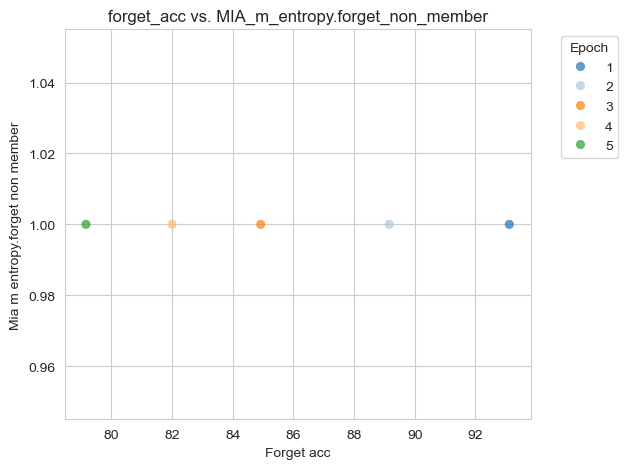

In [18]:
results = gather_results("results/seed_3007") 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results[results.method == "FT"], 
    x_metric = "forget_acc", y_metric = "MIA_m_entropy.forget_non_member", 
    color_by = "epoch"
    )